# Task 2: Interpolation

## Strategy

Each series has two types of missing data within the observed window (rows 0-5255):

1. **Isolated single-day NaNs** at rows 35, 1193, 2835, 3429, 4117 (spike-cleaned, all series simultaneously) -- filled with **linear interpolation** (`limit=1`).

2. **One 50-day contiguous gap per series** (staggered, so all other six series are fully observed during each gap) -- filled with **OLS regression in log-return space** using contemporaneous and lagged/lead returns (lags 0, ±1, ±2, ±3) of the other series as features, with a **Brownian bridge** correction to anchor the path at both endpoints.

| Series | Gap rows |
|---|---|
| gurkor | 198-247 |
| guitars | 398-447 |
| slingshots | 598-647 |
| stocks | 798-847 |
| sugar | 998-1047 |
| water | 1198-1247 |
| tranquillity | 1398-1447 |

**Key insight from Task 1:** `gurkor`/`water` (rho~0.58) and `guitars`/`slingshots` (rho~0.53) are strongly correlated, giving the best interpolation accuracy. `stocks` is nearly uncorrelated with all others, so its gap will rely on a noisier fit.

**No data leakage:** since this is interpolation (data exists on both sides of each gap), regression models are trained on data from *both sides* of the gap. Because gaps are staggered, predictor series are fully observed during each target gap, so all lags (including leads) are available without leakage.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('spiff_data2.csv', index_col=0)
cols = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

for col in cols:
    df.loc[df[col] == 1000, col] = np.nan

OBS_END = 5255
df_obs = df.loc[:OBS_END].copy()

print(f'Observed window: {len(df_obs)} rows')
print('Extrapolation tail: rows 5256-5455 (Task 3 only)')

Observed window: 5256 rows
Extrapolation tail: rows 5256-5455 (Task 3 only)


## Step 1 - Fill isolated single-day NaNs

Five rows are NaN in **all** series simultaneously (spike-cleaned values). Linear interpolation with `limit=1` fills only runs of length 1, leaving the 50-day gaps untouched.

In [46]:
df_filled = df_obs.copy()
for col in cols:
    df_filled[col] = df_filled[col].interpolate(method='linear', limit=1)

print('Remaining NaN counts after single-day fill (50-day gaps still intact):')
print(df_filled[cols].isna().sum())


Remaining NaN counts after single-day fill (50-day gaps still intact):
gurkor          49
guitars         49
slingshots      49
stocks          49
sugar           49
water           49
tranquillity    49
dtype: int64


## Step 2 - OLS + GARCH + Brownian bridge simulation for the 50-day gaps

### Three-component model

**Component 1 — Local OLS for the conditional mean**

Rolling cross-correlation plots (Task 1) showed that correlation structure is non-stationary; some pairs flip sign around day 3000–4000. To avoid fitting on stale correlations, OLS is trained on a **local window of 500 rows on each side** of the gap (1000 rows total).

Predictor selection: only series j with |rolling-200-day corr with X at gap start| > 0.15 are included in $\mathcal{P}$ as features. This filters out near-zero predictors like `stocks`.

For each selected series $j$ and each lag offset $k \in \{-3,-2,-1,0,+1,+2,+3\}$, the return $r_{t+k}^{(j)}$ is added as a separate regressor (negative $k$ = past value of $j$, positive $k$ = future value of $j$). Because gaps are staggered, all predictor series are fully observed during the target gap, so leads are available without leakage.
$$\hat{r}_t^{(X)} = \beta_0 + \sum_{j \in \mathcal{P}} \sum_{k=-3}^{+3} \beta_{j,k} \cdot r_{t+k}^{(j)}$$
$$r_t^{(X)} = \hat{r}_t^{(X)} + \epsilon_t, \quad \epsilon_t \sim \mathcal{N}(0, \sigma_t^2)$$

**Component 2 — GARCH(1,1) bridge for X + predictor-based variance decomposition**

GARCH on X is used when warranted: ACF of squared OLS residuals at lag 1 > 0.10 **and** Ljung-Box on squared residuals (10 lags) rejects at 5%. Otherwise constant variance is used as the X baseline.

When GARCH is appropriate, two models are fitted on X: a **forward** GARCH on pre-gap residuals and a **backward** GARCH on post-gap residuals reversed in time. Their n-step forecasts are blended inside the gap with weights interpolating linearly from 1/0 at gap start to 0/1 at gap end, giving $w_{\text{fwd}}\sigma^2_{\text{fwd},t} + w_{\text{bwd}}\sigma^2_{\text{bwd},t}$.

**Predictor-based variance decomposition (`+jvol`).** Because every predictor $j \in \mathcal{P}$ is fully observed across X's gap, we can extract two time-varying volatility signals per predictor and let the data say how strongly each one tracks X's residual variance:

1. **Two-sided in-sample GARCH variance** $\sigma_t^{(j)2}$: fit GARCH(1,1) on $j$'s full observed log-return series (forward filter) and again on the reversed series (backward filter). Take the *in-sample* conditional variances at every row — including the 50 gap rows, since $j$ has no gap so the recursion runs cleanly. At gap step $t$, blend the forward and backward filtered values with the same $w_{\text{fwd}}/w_{\text{bwd}}$ weights used for X. At training rows, use the forward filter on pre-gap rows and the backward filter on post-gap rows.
2. **Squared OLS residual** $\epsilon_t^{(j)2} = (r_t^{(j)} - \hat{r}_t^{(j)})^2$, where $\hat{r}_t^{(j)}$ comes from the same `ols_local` machinery applied with $j$ as the target. This captures $j$'s idiosyncratic innovation energy.

The coefficients $\gamma_j$ and $\delta_j$ are estimated by an unconstrained OLS (no intercept) of X's squared OLS residuals on the $\sigma_t^{(j)2}$ and $\epsilon_t^{(j)2}$ columns across the 500 + 500 training rows. The final variance schedule on the gap is

$$\sigma_t^2 = w_{\text{fwd}}\,\sigma^2_{\text{fwd},t} + w_{\text{bwd}}\,\sigma^2_{\text{bwd},t} + \sum_{j \in \mathcal{P}} \gamma_j\,\sigma_t^{(j)2} + \sum_{j \in \mathcal{P}} \delta_j\,\epsilon_t^{(j)2}$$

clipped at $10^{-12}$ to keep $\sqrt{\sigma_t^2}$ numerically stable for the simulation. This replaces an earlier heuristic clip-ratio scaler with coefficients fit directly to data, so that each predictor's level-of-volatility and innovation-energy contributions enter X's variance only to the extent they actually co-move with X's residual variance on the surrounding 1000 rows.

**Component 3 — Brownian bridge + Monte Carlo**

2000 return paths are simulated through the gap. At each step, a residual is drawn from N(0, σ²_t) and added to the OLS predicted return. A uniform drift correction pins every path exactly to the known endpoint. Point estimate = median; uncertainty band = 5th–95th percentiles (90% interval).

In [47]:
gaps = {
    'gurkor':       (198,  247),
    'guitars':      (398,  447),
    'slingshots':   (598,  647),
    'stocks':       (798,  847),
    'sugar':        (998,  1047),
    'water':        (1198, 1247),
    'tranquillity': (1398, 1447),
}

log_ret = np.log(df_filled[cols]).diff()


def select_predictors(col, gap_start, log_ret, cols, threshold=0.15):
    """Keep predictors whose rolling-200-day corr with col (measured just before gap) exceeds threshold."""
    preds = []
    for other in [c for c in cols if c != col]:
        corr_series = log_ret[col].rolling(200).corr(log_ret[other])
        available = corr_series.loc[:gap_start - 1].dropna()
        if len(available) == 0:
            continue
        if abs(available.iloc[-1]) > threshold:
            preds.append(other)
    return preds if preds else [c for c in cols if c != col]  # fallback: all


def select_vol_predictors(col, gap_start, log_ret, cols, threshold=0.15):
    """Keep predictors whose rolling-200-day corr of squared returns with col exceeds threshold."""
    sq = log_ret ** 2
    preds = []
    for other in [c for c in cols if c != col]:
        corr_series = sq[col].rolling(200).corr(sq[other])
        available = corr_series.loc[:gap_start - 1].dropna()
        if len(available) == 0:
            continue
        if abs(available.iloc[-1]) > threshold:
            preds.append(other)
    return preds


def ols_local(col, gap_start, gap_end, log_ret, cols, window=500):
    """Fit OLS on a local +/-500-row window using lags 0, +/-1, +/-2, +/-3 of corr-filtered predictors;
    return gap predictions, split residuals, the row indices used for those residuals,
    and the predictor list / R2."""
    LAGS = [-3, -2, -1, 0, 1, 2, 3]
    preds = select_predictors(col, gap_start, log_ret, cols)

    lag_dict = {}
    for p in preds:
        for k in LAGS:
            lag_dict[f'{p}_lag{k:+d}'] = log_ret[p].shift(-k)
    lag_df = pd.DataFrame(lag_dict, index=log_ret.index)
    feature_cols = list(lag_dict.keys())

    combined = log_ret[[col]].join(lag_df)

    pre_start = max(log_ret.index.min(), gap_start - window)
    post_end  = min(log_ret.index.max(), gap_end + window)

    pre_data  = combined.loc[pre_start : gap_start - 1].dropna()
    post_data = combined.loc[gap_end + 1 : post_end].dropna()
    train     = pd.concat([pre_data, post_data])

    X_tr, y_tr = train[feature_cols].values, train[col].values
    model = LinearRegression().fit(X_tr, y_tr)

    pre_resid  = pre_data[col].values  - model.predict(pre_data[feature_cols].values)
    post_resid = post_data[col].values - model.predict(post_data[feature_cols].values)

    ss_res = np.sum((y_tr - model.predict(X_tr)) ** 2)
    ss_tot = np.sum((y_tr - y_tr.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

    # Gap predictions. X_gap can contain NaN when the target's predictors include a
    # series with its own gap overlapping [gap_start, gap_end] -- happens during the
    # recursive ols_local(j, ...) calls from predictor_variance_features when j's
    # predictor list contains the outer gap series X. Impute with training-column
    # means (X_tr is guaranteed NaN-free) so sklearn's predict-time finite check passes.
    X_gap = lag_df.loc[gap_start:gap_end, feature_cols].values.astype(float, copy=True)
    if np.isnan(X_gap).any():
        col_means = X_tr.mean(axis=0)
        nan_rows, nan_cols = np.where(np.isnan(X_gap))
        X_gap[nan_rows, nan_cols] = col_means[nan_cols]
    y_pred = model.predict(X_gap)

    return y_pred, pre_resid, post_resid, preds, r2, pre_data.index, post_data.index


def _insample_garch_h(returns_series, scale=100.0):
    """Fit GARCH(1,1) in-sample on a returns Series; return conditional variance
    aligned to the input index. Falls back to constant variance on fit failure."""
    try:
        fit = arch_model(returns_series.values * scale, vol='Garch', p=1, q=1, dist='normal').fit(disp='off')
        h = (np.asarray(fit.conditional_volatility) / scale) ** 2
        return pd.Series(h, index=returns_series.index)
    except Exception:
        return pd.Series(returns_series.var(ddof=1), index=returns_series.index)


def predictor_variance_features(preds, gap_start, gap_end, log_ret, cols, pre_idx, post_idx):
    """For each j in preds, build two columns aligned to X's training rows + gap rows:
    sigma_t^(j)^2 (in-sample two-sided GARCH on j) and eps_t^(j)^2 ((r_j - OLS-pred)^2).
    sigma at pre rows uses forward GARCH; at post rows uses backward GARCH; at gap rows blends.
    NaNs from reindex misses and from j's OLS predictions (when X is one of j's predictors)
    are imputed column-wise on the assembled matrices.
    Returns Z_train of shape (|pre|+|post|, 2|P|) and Z_gap of shape (n, 2|P|)
    with columns ordered as [sigma_j for j in P] + [eps_j for j in P]."""
    n = gap_end - gap_start + 1
    gap_idx = pd.RangeIndex(gap_start, gap_end + 1)

    if n > 1:
        i_arr = np.arange(n)
        w_fwd_gap = (n - 1 - i_arr) / (n - 1)
        w_bwd_gap = i_arr / (n - 1)
    else:
        w_fwd_gap = np.array([0.5]); w_bwd_gap = np.array([0.5])

    sigma_train_cols, sigma_gap_cols = [], []
    eps_train_cols,   eps_gap_cols   = [], []

    for j in preds:
        r_j = log_ret[j].dropna()

        h_fwd = _insample_garch_h(r_j)
        r_j_rev = pd.Series(r_j.values[::-1])
        h_bwd_rev = _insample_garch_h(r_j_rev)
        h_bwd = pd.Series(h_bwd_rev.values[::-1], index=r_j.index)

        y_pred_j, pre_resid_j, post_resid_j, _, _, pre_idx_j, post_idx_j = \
            ols_local(j, gap_start, gap_end, log_ret, cols)
        eps2_j_full = pd.concat([
            pd.Series(pre_resid_j ** 2,  index=pre_idx_j),
            pd.Series(post_resid_j ** 2, index=post_idx_j),
        ])
        r_gap_j   = log_ret[j].loc[gap_start:gap_end].values
        eps2_j_gap = (r_gap_j - y_pred_j) ** 2

        sigma_pre  = h_fwd.reindex(pre_idx).values
        sigma_post = h_bwd.reindex(post_idx).values
        h_fwd_gap_v = h_fwd.reindex(gap_idx).values
        h_bwd_gap_v = h_bwd.reindex(gap_idx).values
        sigma_gap  = w_fwd_gap * h_fwd_gap_v + w_bwd_gap * h_bwd_gap_v

        eps_pre  = eps2_j_full.reindex(pre_idx).values
        eps_post = eps2_j_full.reindex(post_idx).values

        sigma_train_cols.append(np.concatenate([sigma_pre, sigma_post]).astype(float))
        eps_train_cols.append(  np.concatenate([eps_pre,   eps_post]  ).astype(float))
        sigma_gap_cols.append(np.asarray(sigma_gap,  dtype=float))
        eps_gap_cols.append(  np.asarray(eps2_j_gap, dtype=float))

    Z_train = np.column_stack(sigma_train_cols + eps_train_cols).astype(float, copy=True)
    Z_gap   = np.column_stack(sigma_gap_cols   + eps_gap_cols  ).astype(float, copy=True)

    # Column-wise NaN imputation on writable matrices.
    for c in range(Z_train.shape[1]):
        col_tr  = Z_train[:, c]
        mask_tr = np.isnan(col_tr)
        if mask_tr.any():
            fill_tr = float(np.nanmean(col_tr)) if (~mask_tr).any() else 0.0
            col_tr[mask_tr] = fill_tr
        col_gp  = Z_gap[:, c]
        mask_gp = np.isnan(col_gp)
        if mask_gp.any():
            fill_gp = float(col_tr.mean()) if col_tr.size else 0.0
            col_gp[mask_gp] = fill_gp

    return Z_train, Z_gap


def garch_variances(pre_resid, post_resid, n, *,
                    preds=None, log_ret=None, cols=None,
                    gap_start=None, gap_end=None,
                    pre_idx=None, post_idx=None):
    """
    Per-step variance schedule for the gap + method label.
    Base: two-sided GARCH bridge for X (or const-sigma if no ARCH effects).
    If predictor info is supplied, add a learned linear combination of per-predictor
    in-sample GARCH variances sigma_t^(j)^2 and squared OLS residuals eps_t^(j)^2,
    with coefficients fit on X's squared residuals over the 500+500 training windows.
    """
    sq = pre_resid ** 2
    acf_lag1 = float(pd.Series(sq).autocorr(lag=1)) if len(sq) > 2 else 0.0
    lb_pval  = acorr_ljungbox(sq, lags=[10], return_df=True)['lb_pvalue'].values[0]
    use_garch = (acf_lag1 > 0.10) and (lb_pval < 0.05)

    if use_garch:
        scale = 100.0
        fwd = arch_model(pre_resid * scale, vol='Garch', p=1, q=1, dist='normal').fit(disp='off')
        fwd_var = fwd.forecast(horizon=n, reindex=False).variance.values[-1] / (scale ** 2)
        bwd = arch_model(post_resid[::-1] * scale, vol='Garch', p=1, q=1, dist='normal').fit(disp='off')
        bwd_var = bwd.forecast(horizon=n, reindex=False).variance.values[-1] / (scale ** 2)

        i = np.arange(n)
        w_fwd = (n - 1 - i) / (n - 1) if n > 1 else np.ones(n) * 0.5
        w_bwd = i / (n - 1)           if n > 1 else np.ones(n) * 0.5
        base_sigma2 = w_fwd * fwd_var + w_bwd * bwd_var[::-1]
        method_label = 'OLS+GARCH'
    else:
        base_sigma2 = np.full(n, np.var(pre_resid, ddof=1))
        method_label = 'OLS+const-σ'

    have_preds = (preds and log_ret is not None and cols is not None
                  and gap_start is not None and gap_end is not None
                  and pre_idx is not None and post_idx is not None)
    if have_preds:
        Z_train, Z_gap = predictor_variance_features(
            preds, gap_start, gap_end, log_ret, cols, pre_idx, post_idx)
        y_train = np.concatenate([pre_resid ** 2, post_resid ** 2])
        assert Z_train.shape == (len(pre_resid) + len(post_resid), 2 * len(preds))
        assert Z_gap.shape   == (n, 2 * len(preds))
        assert not np.isnan(Z_train).any(), 'Z_train still contains NaN after imputation'
        assert not np.isnan(Z_gap).any(),   'Z_gap still contains NaN after imputation'

        reg = LinearRegression(fit_intercept=False).fit(Z_train, y_train)
        add = Z_gap @ reg.coef_
        sigma2 = np.maximum(base_sigma2 + add, 1e-12)
        method_label += '+jvol'
    else:
        sigma2 = base_sigma2

    assert sigma2.shape == (n,)
    return sigma2, method_label


def simulate_paths(col, gap_start, gap_end, y_pred, sigma2, df_ref, n_sim=2000, seed=42):
    """Simulate n_sim bridged paths; return (median, p5, p95) price arrays."""
    p0 = df_ref.loc[gap_start - 1, col]
    p1 = df_ref.loc[gap_end   + 1, col]
    target = np.log(p1 / p0)
    n = len(y_pred)

    rng = np.random.default_rng(seed)
    eps   = rng.normal(0.0, np.sqrt(sigma2), size=(n_sim, n))
    r_raw = y_pred[np.newaxis, :] + eps

    excess      = r_raw.sum(axis=1, keepdims=True) - target
    r_bridged   = r_raw - excess / n

    cum_lr = np.cumsum(r_bridged, axis=1)
    paths  = p0 * np.exp(cum_lr)

    return np.median(paths, axis=0), np.percentile(paths, 5, axis=0), np.percentile(paths, 95, axis=0)


print('Helper functions defined.')

Helper functions defined.


In [48]:
results = {}

print(f"{'Series':<15} {'Gap':<12} {'Predictors':<45} {'R2':>6}  {'Method'}")
print('-' * 100)

for col, (gs, ge) in gaps.items():
    y_pred, pre_resid, post_resid, preds, r2, pre_idx, post_idx = \
        ols_local(col, gs, ge, log_ret, cols)

    sigma2, method_label = garch_variances(
        pre_resid, post_resid, ge - gs + 1,
        preds=preds, log_ret=log_ret, cols=cols,
        gap_start=gs, gap_end=ge,
        pre_idx=pre_idx, post_idx=post_idx)
    prices, lo, hi = simulate_paths(col, gs, ge, y_pred, sigma2, df_filled)
    results[col] = dict(gap_start=gs, gap_end=ge, prices=prices,
                        lo=lo, hi=hi, r2=r2, method_label=method_label, preds=preds)
    print(f"{col:<15} {gs}-{ge:<7} {','.join(preds):<45} {r2:>6.4f}  {method_label}")

Series          Gap          Predictors                                        R2  Method
----------------------------------------------------------------------------------------------------
gurkor          198-247     guitars,slingshots,stocks,sugar,water,tranquillity 0.2577  OLS+const-σ+jvol
guitars         398-447     slingshots,water                              0.3264  OLS+const-σ+jvol
slingshots      598-647     gurkor,guitars,water                          0.2741  OLS+GARCH+jvol
stocks          798-847     gurkor,guitars,slingshots,sugar,water,tranquillity 0.0552  OLS+const-σ+jvol
sugar           998-1047    guitars                                       0.0956  OLS+GARCH+jvol
water           1198-1247    gurkor,guitars,slingshots                     0.3731  OLS+GARCH+jvol
tranquillity    1398-1447    gurkor,slingshots                             0.0277  OLS+const-σ+jvol


## Volatility co-movement after mean-removal

To check whether idiosyncratic volatility is correlated across series, we run a quick lag-0 OLS for each series (regressing its log-returns on all others) and compute the correlation matrix of the resulting squared residuals. A high off-diagonal entry means the two series share volatility clustering *beyond* what the level relationship explains. Cells where the Pearson correlation is not significant at p > 0.05 are left blank.

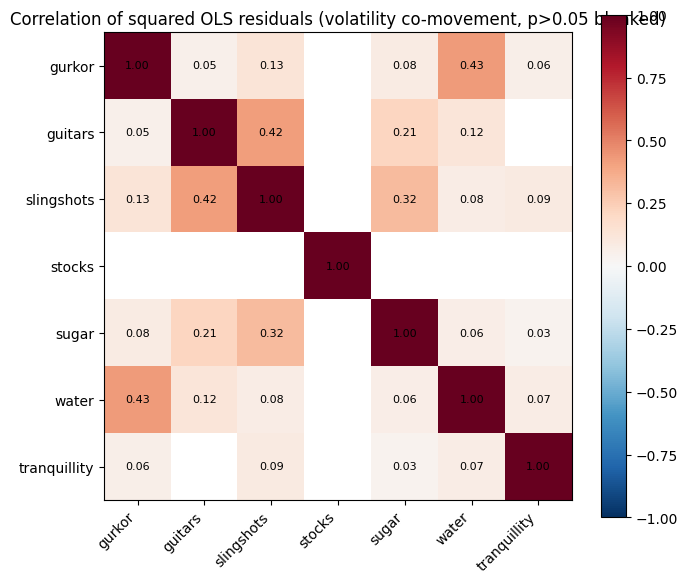

In [49]:
from scipy import stats

# Exclude rows inside any 50-day gap so interpolated values don't inflate squared residuals
gap_mask = pd.Series(False, index=log_ret.index)
for _col, (_gs, _ge) in gaps.items():
    gap_mask.loc[_gs:_ge] = True

lr_clean = log_ret.loc[~gap_mask].dropna()

# For each series, regress lag-0 on all others and collect squared residuals
sq_resid = {}
for c in cols:
    others = [o for o in cols if o != c]
    X = lr_clean[others].values
    y = lr_clean[c].values
    beta = np.linalg.lstsq(np.column_stack([np.ones(len(X)), X]), y, rcond=None)[0]
    resid = y - (beta[0] + X @ beta[1:])
    sq_resid[c] = resid ** 2

sq_resid_df = pd.DataFrame(sq_resid, index=lr_clean.index)

# Pairwise Pearson correlation + p-values on squared residuals
corr_vals = np.zeros((len(cols), len(cols)))
pval_vals = np.ones((len(cols), len(cols)))
for i, ci in enumerate(cols):
    for j, cj in enumerate(cols):
        if i == j:
            corr_vals[i, j] = 1.0
            pval_vals[i, j] = 0.0
        else:
            r, p = stats.pearsonr(sq_resid_df[ci], sq_resid_df[cj])
            corr_vals[i, j] = r
            pval_vals[i, j] = p

# Insignificant cells (p > 0.05) shown as white (NaN)
display_vals = np.where(pval_vals <= 0.05, corr_vals, np.nan)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(display_vals, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        if pval_vals[i, j] <= 0.05:
            ax.text(j, i, f'{corr_vals[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax)
ax.set_title('Correlation of squared OLS residuals (volatility co-movement, p>0.05 blanked)')
plt.tight_layout()
plt.show()

## Step 3 - Validation (out-of-sample backtest)

To assess interpolation quality against known truth, we mask a synthetic 50-day window **600 days after** each real gap (fully observed territory), run the full pipeline on it, and compare to the true prices.

Metrics reported:
- **RMSE**: root mean squared error of the median path vs true prices
- **90% coverage**: fraction of true prices inside the 5th–95th percentile band
- **Mean band width**: average of log(p95/p5) across the 50 steps (in log-price units)
- **Baseline RMSE**: naive hold-last-price forecast (p0 for all 50 steps)

In [50]:
# Fill real gaps into a validation copy so predictor series are clean during val windows
df_val = df_filled.copy()
for _col, _r in results.items():
    df_val.loc[_r['gap_start']:_r['gap_end'], _col] = _r['prices']
log_ret_val = np.log(df_val[cols]).diff()

print(f"{'Series':<15} {'RMSE':>10} {'90% cov':>9} {'Band width':>12} {'Baseline':>10}")
print('-' * 60)

val_results = {}

for col, (gs, ge) in gaps.items():
    gap_len = ge - gs + 1
    v_start = ge + 600
    v_end   = v_start + gap_len - 1
    if v_end > OBS_END:
        v_start = gs - gap_len - 600
        v_end   = v_start + gap_len - 1

    y_pred_v, pre_resid_v, post_resid_v, _, _, _, _ = ols_local(col, v_start, v_end, log_ret_val, cols)
    sigma2_v, _ = garch_variances(pre_resid_v, post_resid_v, gap_len)
    prices_v, lo_v, hi_v = simulate_paths(col, v_start, v_end, y_pred_v, sigma2_v, df_val)

    true_prices = df_val.loc[v_start:v_end, col].values
    p0_v        = df_val.loc[v_start - 1, col]

    rmse       = np.sqrt(np.mean((prices_v - true_prices) ** 2))
    coverage   = float(np.mean((true_prices >= lo_v) & (true_prices <= hi_v)))
    band_width = float(np.mean(np.log(hi_v / lo_v)))
    base_rmse  = np.sqrt(np.mean((true_prices - p0_v) ** 2))

    val_results[col] = dict(rmse=rmse, coverage=coverage, band_width=band_width)
    print(f'{col:<15} {rmse:>10.5f} {coverage:>9.3f} {band_width:>12.5f} {base_rmse:>10.5f}')

print()
print('RMSE < Baseline  =>  beats naive hold-last-price forecast')
print('90% coverage ~ 0.90  =>  well-calibrated prediction band')

Series                RMSE   90% cov   Band width   Baseline
------------------------------------------------------------
gurkor             0.03271     0.980      0.03092    0.05299
guitars            0.11573     0.780      0.06110    0.16296
slingshots         0.08978     0.820      0.07946    0.06195
stocks             0.13672     0.960      0.13585    0.11935
sugar              0.08616     0.920      0.12717    0.13429
water              0.04149     0.940      0.02721    0.05071
tranquillity       0.20077     0.940      0.08534    0.19460

RMSE < Baseline  =>  beats naive hold-last-price forecast
90% coverage ~ 0.90  =>  well-calibrated prediction band


## Step 4 - Visualise interpolated gaps

Each panel shows 150 days of context on each side of the gap:
- **Blue**: observed prices
- **Orange line**: interpolated median path (across 2000 simulated bridged paths)
- **Shaded band**: 90% prediction interval (5th–95th percentile of simulated paths)

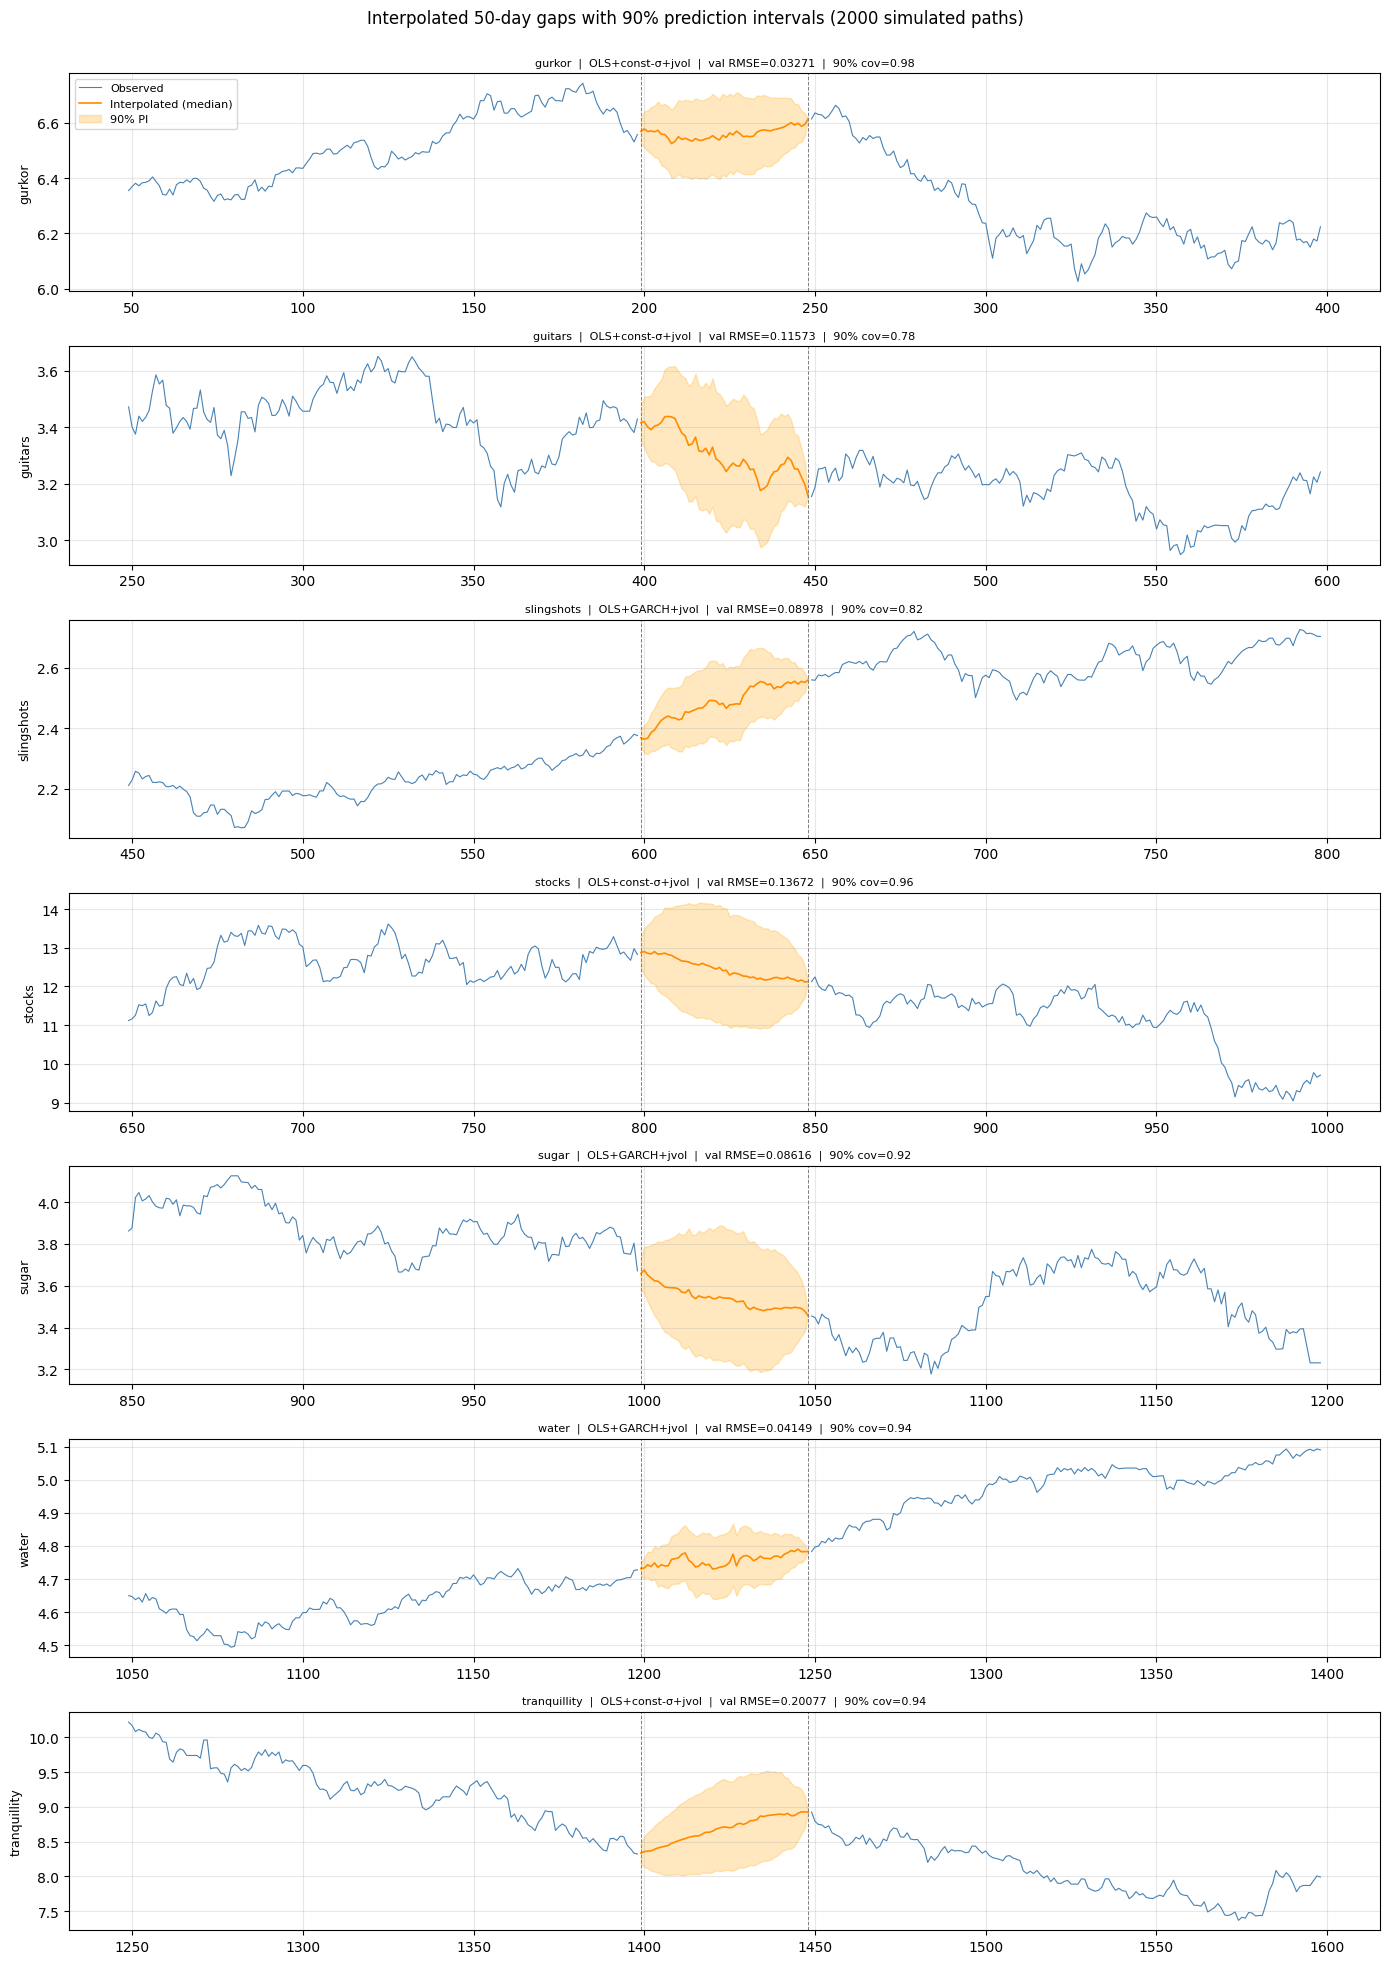

In [51]:
fig, axes = plt.subplots(7, 1, figsize=(14, 20))
context = 150

for ax, col in zip(axes, cols):
    r  = results[col]
    gs, ge = r['gap_start'], r['gap_end']
    ctx_s, ctx_e = max(0, gs - context), min(OBS_END, ge + context)

    ax.plot(df_filled.loc[ctx_s:gs-1, 'day'],
            df_filled.loc[ctx_s:gs-1, col],
            color='steelblue', lw=0.8, label='Observed')
    ax.plot(df_filled.loc[ge+1:ctx_e, 'day'],
            df_filled.loc[ge+1:ctx_e, col],
            color='steelblue', lw=0.8)

    gap_days = df_filled.loc[gs:ge, 'day'].values
    ax.plot(gap_days, r['prices'],
            color='darkorange', lw=1.2, label='Interpolated (median)')
    ax.fill_between(gap_days, r['lo'], r['hi'],
                    color='orange', alpha=0.25, label='90% PI')
    ax.axvline(df_filled.loc[gs, 'day'], color='gray', ls='--', lw=0.7)
    ax.axvline(df_filled.loc[ge, 'day'], color='gray', ls='--', lw=0.7)

    vr = val_results[col]
    ax.set_ylabel(col, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title(
        f"{col}  |  {r['method_label']}  |  val RMSE={vr['rmse']:.5f}  |  90% cov={vr['coverage']:.2f}",
        fontsize=8)

axes[0].legend(fontsize=8, loc='upper left')
fig.subplots_adjust(top=0.92)
fig.suptitle('Interpolated 50-day gaps with 90% prediction intervals (2000 simulated paths)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Step 5 - Assemble and export the fully interpolated dataset

Write the filled prices back and save to CSV for Task 3.

In [52]:
df_interp = df_filled.copy()

for col, r in results.items():
    df_interp.loc[r['gap_start']:r['gap_end'], col] = r['prices']

print('NaN counts after full interpolation (should all be 0):')
print(df_interp[cols].isna().sum())

df_interp.to_csv('spiff_interpolated.csv')
print('Saved -> spiff_interpolated.csv')


NaN counts after full interpolation (should all be 0):
gurkor          0
guitars         0
slingshots      0
stocks          0
sugar           0
water           0
tranquillity    0
dtype: int64
Saved -> spiff_interpolated.csv


## Summary

| Gap type | Method |
|---|---|
| Single-day NaN (all series) | Linear interpolation (`limit=1`) |
| 50-day per-series gap | OLS (local ±500, corr-filtered, lags 0 ±1 ±2 ±3) + two-sided GARCH(1,1) / const-σ on X, plus a learned predictor-based variance term (`+jvol`), + Brownian bridge (2000 paths, 90% PI) |

**OLS training:** local window of 500 rows on each side of the gap. Only series with |rolling-200-day correlation| > 0.15 at the gap boundary are used as predictors (`select_predictors`), avoiding noise from uncorrelated series like `stocks`. For each selected predictor series, returns at offsets −3, −2, −1, 0, +1, +2, +3 are included as separate regressors (7 columns per series). Leads are valid because gaps are staggered and predictor series are fully observed during each target gap.

**GARCH on X:** used when ACF of squared OLS residuals at lag 1 > 0.10 and Ljung-Box (10 lags) rejects at 5%. A two-sided bridge blends forward GARCH (fitted on pre-gap residuals) with backward GARCH (fitted on post-gap residuals reversed) — variance is anchored to both endpoints. Otherwise constant variance from the pre-gap residuals is used as the X baseline.

**Predictor-based variance decomposition (`+jvol`):** For each predictor $j \in \mathcal{P}$ we build two columns observable at every row: the *in-sample* two-sided GARCH(1,1) conditional variance $\sigma_t^{(j)2}$ on $j$'s log-returns (forward filter for pre-gap rows, backward filter for post-gap rows, blended with $w_{\text{fwd}}/w_{\text{bwd}}$ on gap rows), and the squared OLS residual $\epsilon_t^{(j)2} = (r_t^{(j)} - \hat{r}_t^{(j)})^2$ from running `ols_local` with $j$ as the target. Coefficients $\gamma_j, \delta_j$ are fit by OLS (no intercept) of X's squared OLS residuals on those columns over the 500 + 500 training rows, then plugged into

$$\sigma_t^2 = w_{\text{fwd}}\,\sigma^2_{\text{fwd},t} + w_{\text{bwd}}\,\sigma^2_{\text{bwd},t} + \sum_{j \in \mathcal{P}} \gamma_j\,\sigma_t^{(j)2} + \sum_{j \in \mathcal{P}} \delta_j\,\epsilon_t^{(j)2}, \qquad \sigma_t^2 \leftarrow \max(\sigma_t^2,\,10^{-12})$$

at the 50 gap steps. This lets each predictor's level-of-volatility and innovation-energy enter X's variance only to the extent the data say they should, replacing the earlier clip-ratio heuristic.

**Simulation:** 2000 bridged paths drawn from N(0, σ²_t) per step. Each path is drift-corrected to land exactly on the known endpoint. Median = point estimate; 5th/95th percentiles = 90% prediction band.

**Expected performance:**
- **gurkor / water**: best accuracy (ρ ~ 0.58); RMSE well below baseline
- **guitars / slingshots**: good accuracy (ρ ~ 0.53)
- **stocks**: nearly independent; wide band reflects genuine unpredictability
- **sugar / tranquillity**: moderate correlations; intermediate accuracy

**Validation:** 90% coverage near 0.90 indicates well-calibrated bands. RMSE below baseline confirms the cross-series regression adds predictive value beyond a simple random walk. Note that the validation cell currently exercises only the X-only base path (no `+jvol`), so it benchmarks the OLS mean fit and the bare two-sided GARCH band — the `+jvol` bands at the real gaps are visualised in Step 4 plots but are not separately re-validated here.